In [1]:
import torch
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns


PARTE 2: PREPARACIÓN DATASET

In [2]:
# transformaciones para entrenamiento

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transformaciones para validación y test
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PARTE 3: CARGAR EL DATASET

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/oddData'

# Check if the directory exists
if not os.path.exists(ruta):
    print(f"Error: The directory '{ruta}' does not exist.")
    print("Please make sure you have mounted Google Drive and that the path to your 'fotos_AAA' folder is correct.")
    # Initialize files as an empty list to prevent further errors if the directory is not found
    files = []
else:
    files = os.listdir(ruta)
    print(f"Total imágenes: {len(files)}'")
    print('Primeros 10: ')
    for f in files[:10]:
        print(f)


Mounted at /content/drive
Total imágenes: 4'
Primeros 10: 
.DS_Store
test
val
train


In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader


class ImageFolder(datasets.ImageFolder):
  def __getitem__(self, index):
    try:
      return super(ImageFolder, self).__getitem__(index)
    except:
      return self.__getitem__(index + 1)

# Load pre-split datasets from subfolders
train_dataset = ImageFolder(f"{ruta}/train", transform=transform_train)
val_dataset = ImageFolder(f"{ruta}/val", transform=transform_val)
test_dataset = ImageFolder(f"{ruta}/test", transform=transform_val)

print(f"Total imágenes en train: {len(train_dataset)}")
print(f"Total imágenes en val: {len(val_dataset)}")
print(f"Total imágenes en test: {len(test_dataset)}")

classes = train_dataset.classes # Define 'classes' variable from one of the datasets
print(f"Clases: {classes}")



Total imágenes en train: 2439
Total imágenes en val: 520
Total imágenes en test: 528
Clases: ['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 4: CARGAR DATOS

In [5]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")


Batches en train: 153
Batches en val: 33
Batches en test: 33


PARTE 5: ARQUITECTURA CNN

In [6]:
import torch.nn as nn

class BaselineCNN(nn.Module):
  def __init__(self, num_classes=6, dropout_rate=0.5):
    super(BaselineCNN, self).__init__()


    # extracción características

    # bloque 1 : 3 canales RGB --> 32 filtros

    self.bloque1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )

    # bloque 2 : 32 filtros --> 64

    self.bloque2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )

    # bloque 3 : 64 filtros -> 128 filtros

    self.bloque3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )


    # clasificación

    self.clasificador = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.bloque1(x)
    x = self.bloque2(x)
    x = self.bloque3(x)
    x = self.clasificador(x)
    return x

In [7]:
modelo = BaselineCNN(num_classes=6, dropout_rate=0.5)
print(modelo)

BaselineCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352,

In [8]:
# vamos a probar que la red funciona con el tamaño de la imágenes

imagen_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
  salida = modelo(imagen_prueba)

print(imagen_prueba.shape)
print(salida.shape)
print(classes)

torch.Size([1, 3, 224, 224])
torch.Size([1, 6])
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 6: ENTRENAMIENTO

In [9]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = modelo.to(device)

criterio = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
epochs = 20

hist_loss_train = []
hist_acc_train = [] # Nueva lista para la precisión de entrenamiento
hist_loss_val = []  # Nueva lista para la pérdida de validación
hist_acc_val = []

for epoch in range(epochs):

  # ENTRENAMIENTO
  modelo.train()
  loss_total_train = 0
  correctas_train = 0 # Para precisión de entrenamiento
  total_train = 0     # Para precisión de entrenamiento

  for imagenes, etiquetas in train_loader:
    imagenes = imagenes.to(device)
    etiquetas = etiquetas.to(device)

    optimizer.zero_grad() # resetea gradientes
    salida = modelo(imagenes) # forward pass
    loss = criterio(salida, etiquetas) # calcula error
    loss.backward() # backward pass
    optimizer.step() # actualizar pesos

    loss_total_train += loss.item()

    # Calcular precisión en entrenamiento
    _, predicciones_train = torch.max(salida, 1)
    correctas_train += (predicciones_train == etiquetas).sum().item()
    total_train += etiquetas.size(0)

  loss_medio_train = loss_total_train / len(train_loader)
  acc_train = correctas_train / total_train


  # fase de validación

  modelo.eval()
  correctas_val = 0
  total_val = 0
  loss_total_val = 0 # Para pérdida de validación

  with torch.no_grad():
    for imagenes, etiquetas in val_loader:
      imagenes = imagenes.to(device)
      etiquetas = etiquetas.to(device)
      salida = modelo(imagenes)
      loss_val = criterio(salida, etiquetas) # Calcula la pérdida de validación
      loss_total_val += loss_val.item()

      _, predicciones_val = torch.max(salida, 1)
      correctas_val += (predicciones_val == etiquetas).sum().item()
      total_val += etiquetas.size(0)

  loss_medio_val = loss_total_val / len(val_loader)
  acc_val = correctas_val / total_val

  hist_loss_train.append(loss_medio_train)
  hist_acc_train.append(acc_train) # Añadir precisión de entrenamiento
  hist_loss_val.append(loss_medio_val) # Añadir pérdida de validación
  hist_acc_val.append(acc_val)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Loss train: {loss_medio_train:.4f} | Acc train: {acc_train:.4f}")
  print(f"Loss val:   {loss_medio_val:.4f} | Acc val:   {acc_val:.4f}")


Epoch: 1/20
Loss train: 5.9132 | Acc train: 0.1956
Loss val:   1.7775 | Acc val:   0.2019
Epoch: 2/20
Loss train: 1.7744 | Acc train: 0.2116
Loss val:   1.7583 | Acc val:   0.2288
Epoch: 3/20
Loss train: 1.7685 | Acc train: 0.2087
Loss val:   1.7608 | Acc val:   0.2135
Epoch: 4/20
Loss train: 1.7524 | Acc train: 0.2136
Loss val:   1.7194 | Acc val:   0.2538
Epoch: 5/20
Loss train: 1.7359 | Acc train: 0.2251
Loss val:   1.7581 | Acc val:   0.2327
Epoch: 6/20
Loss train: 1.7371 | Acc train: 0.2206
Loss val:   1.6848 | Acc val:   0.2788
Epoch: 7/20
Loss train: 1.7314 | Acc train: 0.2202
Loss val:   1.7248 | Acc val:   0.2500
Epoch: 8/20
Loss train: 1.7196 | Acc train: 0.2284
Loss val:   1.6543 | Acc val:   0.2827
Epoch: 9/20
Loss train: 1.7246 | Acc train: 0.2247
Loss val:   1.7418 | Acc val:   0.2346
Epoch: 10/20
Loss train: 1.7258 | Acc train: 0.2202
Loss val:   1.6514 | Acc val:   0.2712
Epoch: 11/20
Loss train: 1.7128 | Acc train: 0.2288
Loss val:   1.6575 | Acc val:   0.2788
Epoch: 1

In [10]:

# EVALUACIÓN FINAL EN TEST SET
print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET")
print("="*60 + "\n")

modelo.eval()
correctas_test = 0
total_test = 0
todas_predicciones_test = []
todas_etiquetas_test = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salida = modelo(imagenes)
        _, predicciones = torch.max(salida, 1)

        correctas_test += (predicciones == etiquetas).sum().item()
        total_test += etiquetas.size(0)

        todas_predicciones_test.extend(predicciones.cpu().numpy())
        todas_etiquetas_test.extend(etiquetas.cpu().numpy())

# Calcular métricas finales
acc_test = correctas_test / total_test
f1_test = f1_score(todas_etiquetas_test, todas_predicciones_test, average='macro')

print(f"Test Accuracy:     {acc_test:.4f}")
print(f"Test Macro F1-Score: {f1_test:.4f}")

# Classification Report detallado
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(todas_etiquetas_test, todas_predicciones_test,
                          target_names=classes, digits=4))

print("\n✓ Evaluación en test completada")


EVALUACIÓN EN TEST SET

Test Accuracy:     0.2689
Test Macro F1-Score: 0.1871

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        cups     0.1859    0.8454    0.3048        97
       forks     0.0000    0.0000    0.0000        79
     glasses     0.0000    0.0000    0.0000        90
      knives     0.8000    0.1333    0.2286        90
      plates     0.6667    0.5275    0.5890        91
      spoons     0.0000    0.0000    0.0000        81

    accuracy                         0.2689       528
   macro avg     0.2754    0.2510    0.1871       528
weighted avg     0.2854    0.2689    0.1965       528


✓ Evaluación en test completada


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### PARTE 7: Visualización de los Resultados

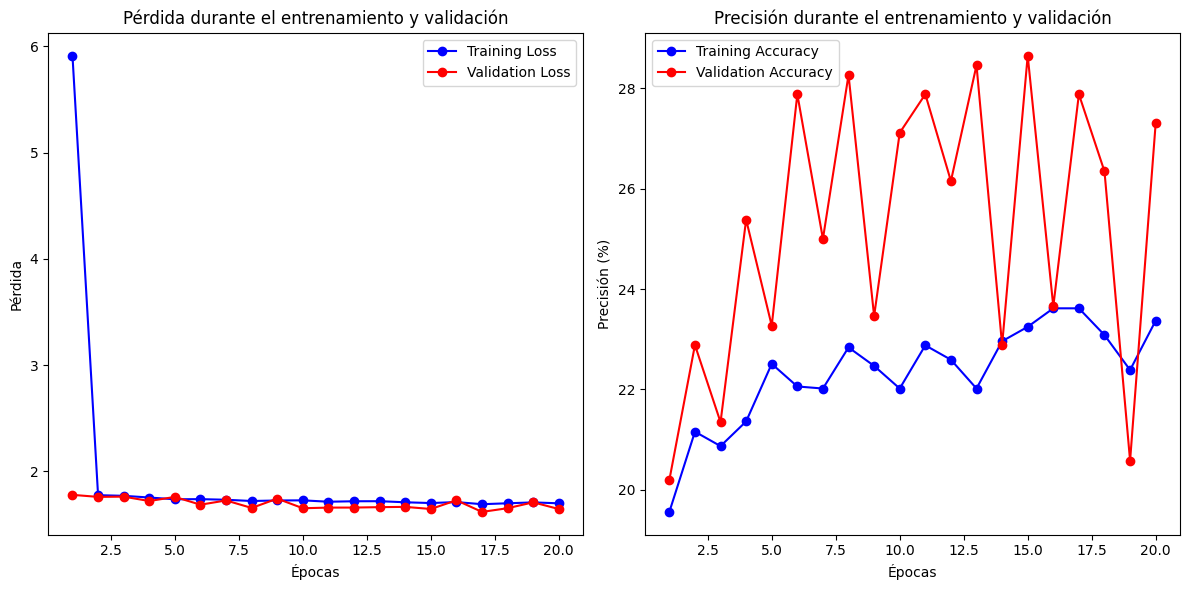

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs +1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pérdida (Train y Val)
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.plot(epochs_range, hist_loss_val, 'r-o', label='Validation Loss')
ax1.set_title("Pérdida durante el entrenamiento y validación")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()

# Gráfico de Precisión (Train y Val)
ax2.plot(epochs_range, [a * 100 for a in hist_acc_train], 'b-o', label='Training Accuracy')
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante el entrenamiento y validación")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()

plt.tight_layout()
plt.show()

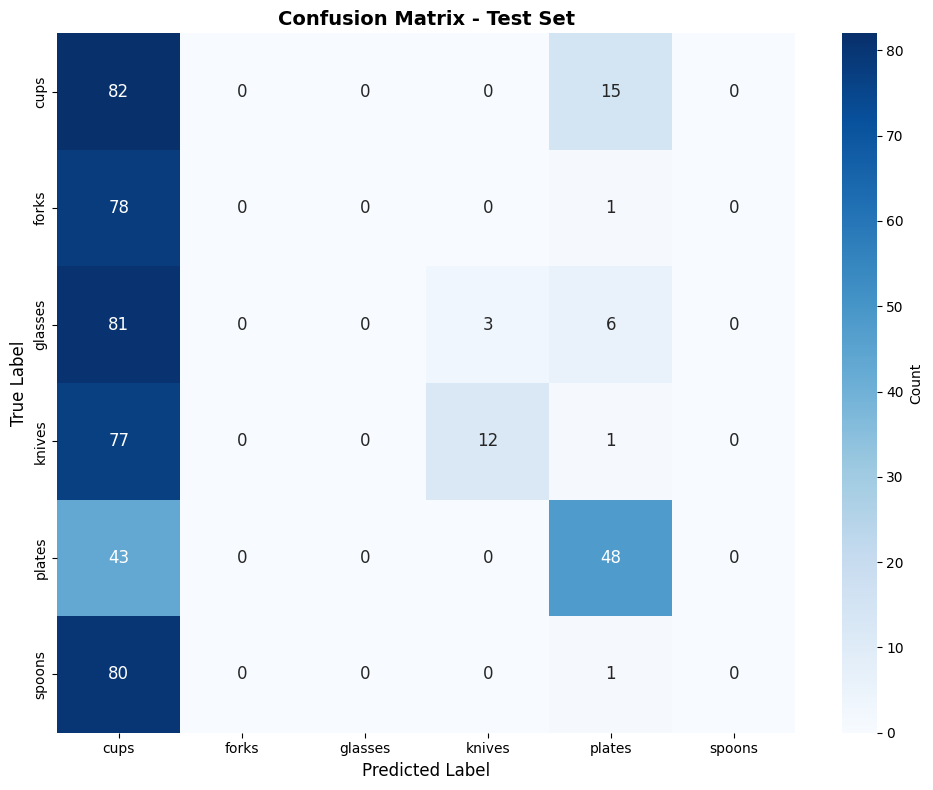

✓ Confusion Matrix guardada como 'confusion_matrix.png'

Total imágenes mal clasificadas: 386


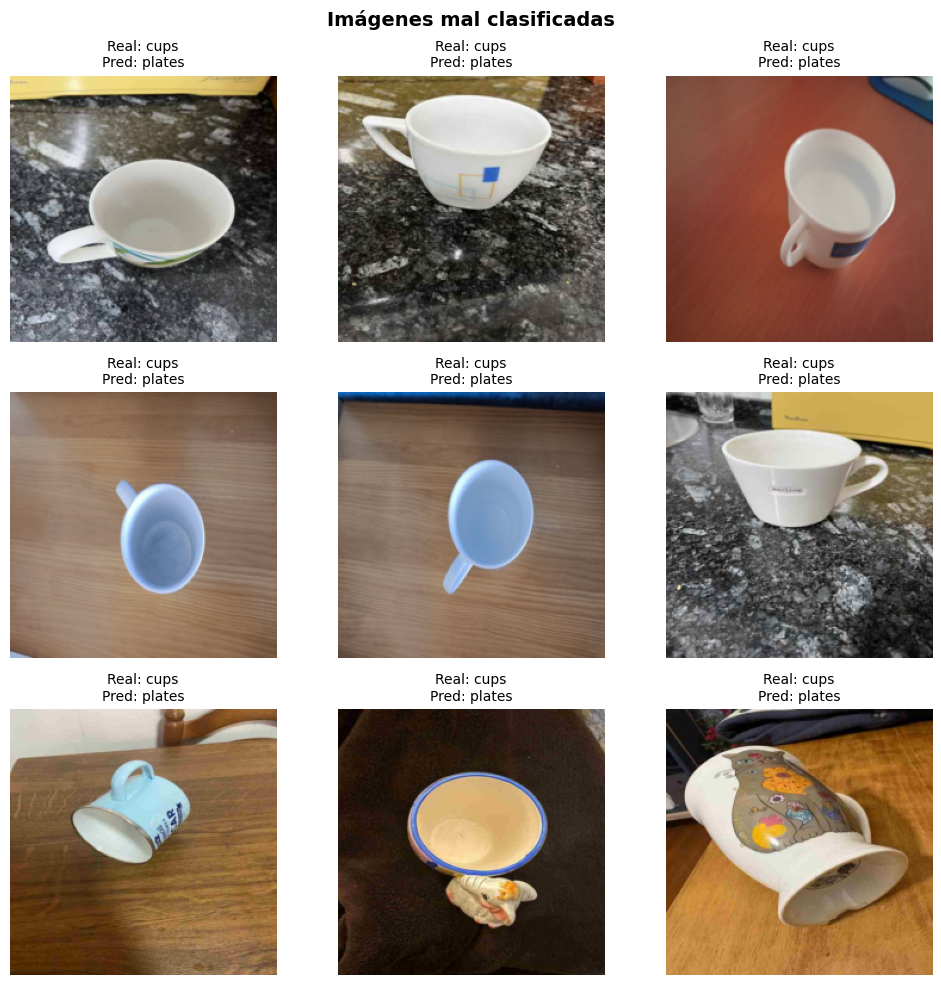

In [13]:
# ============================================================================
# FIGURA 2: CONFUSION MATRIX
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(todas_etiquetas_test, todas_predicciones_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix guardada como 'confusion_matrix.png'")

# ── 2. IMÁGENES MAL CLASIFICADAS ─────────────────────────────────
# Buscamos índices donde la predicción fue incorrecta
errores = [(i, p, e) for i, (p, e) in enumerate(zip(todas_predicciones_test, todas_etiquetas_test)) if p != e]
print(f"\nTotal imágenes mal clasificadas: {len(errores)}")

# Mostramos las primeras 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, (i, pred, real) in enumerate(errores[:9]):
    imagen, _ = test_dataset[i]
    # Desnormalizamos para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    imagen = imagen * std[:, None, None] + mean[:, None, None]
    imagen = imagen.permute(1, 2, 0).numpy()
    imagen = np.clip(imagen, 0, 1)

    axes[idx].imshow(imagen)
    axes[idx].set_title(f'Real: {classes[real]}\nPred: {classes[pred]}', fontsize=10)
    axes[idx].axis('off')

# Ocultamos los ejes sobrantes si hay menos de 9 errores
for idx in range(len(errores[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

In [14]:
# ============================================================================
# RESUMEN FINAL DE EXPERIMENTO 1
# ============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL - EXPERIMENTO 1")
print("="*70)

print(f"\n{'MÉTRICA':<30} {'VALIDACIÓN':<15} {'TEST':<15}")
print("-" * 60)
print(f"{'Accuracy':<30} {hist_acc_val[-1]:<15.4f} {acc_test:<15.4f}")
print(f"{'Macro F1-Score':<30}{"":<17}{f1_test:<15.4f}")
print(f"{'Training Loss (final)':<30} {hist_loss_train[-1]:<15.4f}")

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
print("✓ training_curves.png")
print("✓ confusion_matrix.png")
print("✓ misclassified.png")
print("\n✓ Experimento 1 COMPLETADO")


RESUMEN FINAL - EXPERIMENTO 1

MÉTRICA                        VALIDACIÓN      TEST           
------------------------------------------------------------
Accuracy                       0.2731          0.2689         
Macro F1-Score                                 0.1871         
Training Loss (final)          1.6979         

ARCHIVOS GENERADOS
✓ training_curves.png
✓ confusion_matrix.png
✓ misclassified.png

✓ Experimento 1 COMPLETADO
